In [24]:
import numpy as np
import dython as dt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import optuna

## Dataset

In [25]:
train_path = 'datasets/aerolineas/train.csv'
test_path = 'datasets/aerolineas/test.csv'

In [3]:
def load_dataset(path):
    df = pd.read_csv(path)
    # Drop index-like column
    df.drop(columns=[df.columns[0]], inplace=True)
    # Drop "id" column, since it's useless
    df.drop(columns=[df.columns[0]], inplace=True)
    # Drop nulls.
    df = df[df['Arrival Delay in Minutes'].notnull()]
    # Add target numeric. Will do with encoding.
    #df["satisfacion_num"] = df["satisfaction"].map(
        #{s_lvl: s_int for s_int, s_lvl in enumerate(df["satisfaction"].unique())}
    #)

    return df

In [26]:
train = load_dataset(train_path) 
test = load_dataset(test_path)

## Baseline (Logistic Regression)

### Preprocessing

In [45]:
with pd.option_context('display.max_columns', None):
    display(train.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [31]:
# For logistic regression, we need need all numeric features.
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103594 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103594 non-null  object 
 1   Customer Type                      103594 non-null  object 
 2   Age                                103594 non-null  int64  
 3   Type of Travel                     103594 non-null  object 
 4   Class                              103594 non-null  object 
 5   Flight Distance                    103594 non-null  int64  
 6   Inflight wifi service              103594 non-null  int64  
 7   Departure/Arrival time convenient  103594 non-null  int64  
 8   Ease of Online booking             103594 non-null  int64  
 9   Gate location                      103594 non-null  int64  
 10  Food and drink                     103594 non-null  int64  
 11  Online boarding                    103594 no

In [46]:
# We need gender, customer type, type of travel and class, as well as target.
for colname in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    print(f'{colname} uniques: {train[colname].unique()}')

Gender uniques: ['Male' 'Female']
Customer Type uniques: ['Loyal Customer' 'disloyal Customer']
Type of Travel uniques: ['Personal Travel' 'Business travel']
Class uniques: ['Eco Plus' 'Business' 'Eco']


In [52]:
# We can go binary coding except for Class. We'll use one-hot encoding
# since cardinality is low. 
train = pd.get_dummies(
    train,
    columns=train.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
test = pd.get_dummies(
    test,
    columns=test.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)

In [53]:
with pd.option_context('display.max_columns', None):
    display(test.head())

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus,satisfaction_satisfied
0,52,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,0,0,0,1,0,1
1,36,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,0,0,0,0,0,1
2,20,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,1,1,0,1,0,0
3,44,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,1,0,0,0,0,1
4,49,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,0,0,0,1,0,1


In [77]:
# Get features and targets.
y_train = train['satisfaction_satisfied']
x_train = train.drop(columns=['satisfaction_satisfied'])
y_test = test['satisfaction_satisfied']
x_test = test.drop(columns=['satisfaction_satisfied'])

In [78]:
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 23)
Test Y: (25893,)
Test X: (25893, 23)


### Regression

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [93]:
# Columns to scale. Columns that are a 1 to 5 "satisfaction" score will be #
# scaled with min max, the rest with standard.
scale_cols = [col for col in list(x_train.columns) if "_" not in col]
scale_standr_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
]
scale_minmax_cols = [col for col in scale_cols if col not in scale_standr_cols]

In [94]:
# Pipeline + Fit.
preprocessor = ColumnTransformer(
    transformers=[
        ('ssc', StandardScaler(), scale_standr_cols),
        ('smn', MinMaxScaler(), scale_minmax_cols)
    ]
)

logreg = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LogisticRegressionCV(cv=10, random_state=42)),
    ]
)

logreg.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ssc', ...), ('smn', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


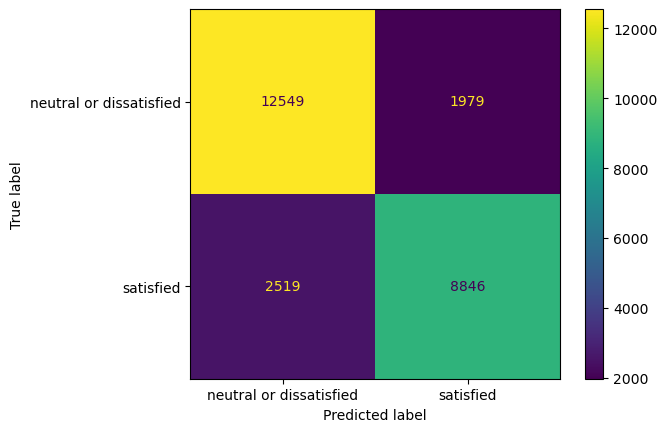

In [95]:
# Confusion matrix to visualize results without threshold optimization.
y_pred = logreg.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    cm, display_labels=['neutral or dissatisfied', 'satisfied']
)
disp.plot()
plt.show()

In [96]:
# Classification report.
print(
    classification_report(
        y_test, y_pred, target_names=['neutral or dissatisfied', 'satisfied']
    )
)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.83      0.86      0.85     14528
              satisfied       0.82      0.78      0.80     11365

               accuracy                           0.83     25893
              macro avg       0.83      0.82      0.82     25893
           weighted avg       0.83      0.83      0.83     25893



### Threshold Tuning

In [122]:
# Tune threshold.
from sklearn.model_selection import TunedThresholdClassifierCV

logreg_optimized = TunedThresholdClassifierCV(
    logreg,
    scoring='roc_auc',
    store_cv_results=True,
)

logreg_optimized.fit(x_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,scoring,'roc_auc'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,True
,transformers,"[('ssc', ...), ('smn', ...)]"
,remainder,'drop'


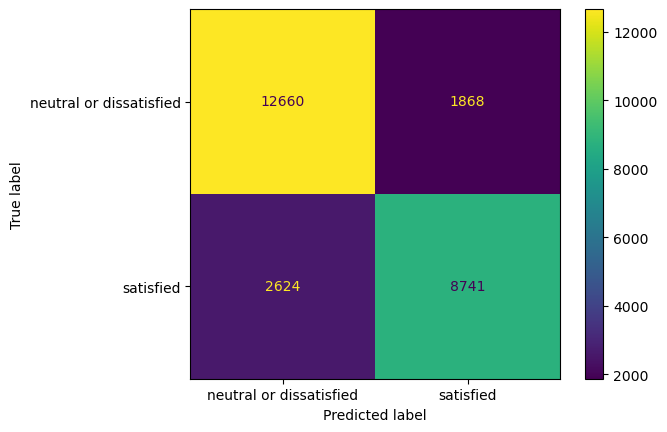

In [125]:
# Confusion matrix to visualize results.
y_pred = logreg_optimized.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    cm, display_labels=['neutral or dissatisfied', 'satisfied']
)
disp.plot()
plt.show()

In [126]:
# Classification report.
print(
    classification_report(
        y_test, y_pred, target_names=['neutral or dissatisfied', 'satisfied']
    )
)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.83      0.87      0.85     14528
              satisfied       0.82      0.77      0.80     11365

               accuracy                           0.83     25893
              macro avg       0.83      0.82      0.82     25893
           weighted avg       0.83      0.83      0.83     25893



In [128]:
from sklearn.metrics import roc_auc_score

# average auc across folds
avg_auc_train = logreg_optimized.best_score_
# Compare auc in the test set.
auc_test_optimized = roc_auc_score(y_test, logreg_optimized.predict(x_test))
auc_test = roc_auc_score(y_test, logreg.predict(x_test))

print(f"Average AUC on the training set: {avg_auc_train:.5f}")
print(f"AUC on the test set: {auc_test_optimized:.5f}")
print(f"AUC on the test set (original model): {auc_test:.5f}")
print(f"Threshold: {logreg_optimized.best_threshold_: .5f}")

Average AUC on the training set: 0.82275
AUC on the test set: 0.82027
AUC on the test set (original model): 0.82107
Threshold:  0.51374


### Conclusion

Optimizing threshold doesn't seem to modify results that much.

Metrics seem to improve slightly and accuracy is barely improved as well. 

At least, we now have a baseline.

## k-NN

### Preprocessing

In [6]:
# We also need all numeric features for k-NN, so we run the same preprocessing
# as with logistic regression.
train = pd.get_dummies(
    train,
    columns=train.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
test = pd.get_dummies(
    test,
    columns=test.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
# Get features and targets.
y_train = train['satisfaction_satisfied']
x_train = train.drop(columns=['satisfaction_satisfied'])
y_test = test['satisfaction_satisfied']
x_test = test.drop(columns=['satisfaction_satisfied'])
# Shapes.
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 23)
Test Y: (25893,)
Test X: (25893, 23)


### Classifier

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score

#### Hyperparameter Search

In [8]:
# Columns to scale. Columns that are a 1 to 5 "satisfaction" score will be #
# scaled with min max, the rest with standard.
scale_cols = [col for col in list(x_train.columns) if "_" not in col]
scale_standr_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
]
scale_minmax_cols = [col for col in scale_cols if col not in scale_standr_cols]

In [9]:
# Pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('ssc', StandardScaler(), scale_standr_cols),
        ('smn', MinMaxScaler(), scale_minmax_cols)
    ]
)

knncls = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('cls', KNeighborsClassifier()),
    ]
)

In [16]:
### Hyperparameter search with optuna.
# Objective function. We'll want to maximize this function.
def objective_fn(trial):
    # Suggest methods of a Trial object to generate hyperparameters.
    hparam_grid = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 100),
        'weights': trial.suggest_categorical(
            'weights', ['uniform', 'distance']
        ),
        'p': trial.suggest_float('p', 1, 100),
    }

    # Model
    model = KNeighborsClassifier(**hparam_grid)

    # Pipeline
    knncls = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('cls', model),
        ]
    )
    
    # Cross validation F1 score. Mean over all cv runs.
    f1score = cross_val_score(
        knncls, x_train, y_train, cv=3, scoring='f1', n_jobs=3
    ).mean()

    return f1score

# Logging callback.
# https://mlflow.org/docs/latest/ml/traditional-ml/tutorials/hyperparameter-tuning/notebooks/hyperparameter-tuning-with-child-runs/#implementing-a-logging-callback
optuna.logging.set_verbosity(optuna.logging.ERROR)
# Define a logging callback that will report on only new challenger 
# parameter configurations if a trial has usurped the state of 'best conditions'.
def champion_callback(study, frozen_trial):
    """
    Logging callback that will report when a new trial iteration improves upon existing
    best trial values.

    Note: This callback is not intended for use in distributed computing systems such as Spark
    or Ray due to the micro-batch iterative implementation for distributing trials to a cluster's
    workers or agents.
    The race conditions with file system state management for distributed trials will render
    inconsistent values with this callback.
    """
    # Get 'winner' if it exists, else None.
    winner = study.user_attrs.get('winner', None)
    # If best value exists and is different from winner.
    if study.best_value and winner != study.best_value:
        # Initialize (or set) best value as 'winner'.
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement_percent = (
                abs(winner - study.best_value) / study.best_value
            ) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(
                f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}"
            )

# Create and optimize study.
study = optuna.create_study(direction='maximize')
study.optimize(objective_fn, n_trials=150, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.8149807105070885
Trial 4 achieved value: 0.8284220588881276 with  1.6225% improvement
Trial 10 achieved value: 0.8825363472644394 with  6.1317% improvement
Trial 22 achieved value: 0.8829692520280118 with  0.0490% improvement
Trial 36 achieved value: 0.8864473779123437 with  0.3924% improvement
Trial 62 achieved value: 0.8900582749785012 with  0.4057% improvement
Trial 87 achieved value: 0.8913622137349724 with  0.1463% improvement
Trial 89 achieved value: 0.8919081797917184 with  0.0612% improvement
Trial 122 achieved value: 0.8935063790867219 with  0.1789% improvement


In [17]:
# Hyperparameter search results
print(study.best_params)

{'n_neighbors': 9, 'weights': 'uniform', 'p': 1.0789835506466046}


Best params:

{'n_neighbors': 9, 'weights': 'uniform', 'p': 1.0789835506466046}

## SVM (NO)

Storing the kernel matrix requires memory that scales quadratically with the number of data points. 
Training time for traditional SVM algorithms also scales superlinearly with the number of data points. 
Thus, these algorithms aren't feasible for large data sets.

### Preprocessing

In [12]:
# We also need all numeric features for SMV, so we run the same preprocessing
# as with logistic regression.
train = pd.get_dummies(
    train,
    columns=train.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
test = pd.get_dummies(
    test,
    columns=test.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
# Get features and targets.
y_train = train['satisfaction_satisfied']
x_train = train.drop(columns=['satisfaction_satisfied'])
y_test = test['satisfaction_satisfied']
x_test = test.drop(columns=['satisfaction_satisfied'])
# Shapes.
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 23)
Test Y: (25893,)
Test X: (25893, 23)


### Classifier

In [9]:
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV

#### Hyperparameter Search

In [34]:
# Columns to scale. Columns that are a 1 to 5 "satisfaction" score will be #
# scaled with min max, the rest with standard.
scale_cols = [col for col in list(x_train.columns) if "_" not in col]
scale_standr_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
]
scale_minmax_cols = [col for col in scale_cols if col not in scale_standr_cols]

In [57]:
# Pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('ssc', StandardScaler(), scale_standr_cols),
        ('smn', MinMaxScaler(), scale_minmax_cols)
    ]
)

svccls = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('cls', SVC()),
    ]
)

In [ ]:
hparam_grid = [
    {'cls__C': [0.01, 0.1, 1, 5, 10, 100], 'cls__kernel': ['linear']},
    {
        'cls__C': [0.01, 0.1, 1, 5, 10, 100],
        'cls__degree': [2, 3, 4, 5, 6],
        'cls__kernel': ['poly'],
    },
    {
        'cls__C': [0.01, 0.1, 1, 5, 10, 100],
        'cls__gamma': [0.1, 0.5, 1, 2, 10, 100],
        'cls__kernel': ['rbf', 'sigmoid'],
    },
]

gsearch = GridSearchCV(
    svccls, hparam_grid, scoring="f1", n_jobs=-1, refit=True, cv=3, verbose=1
)
gsearch.fit(x_train, y_train)

In [ ]:
# Grid search results
print(f'{gsearch.best_params_}')
# Best model.
best_svc = gsearch.best_estimator_

## Random Forest

### Preprocessing

In [27]:
# Radom Forest algorithm can use categorical features. 
# But sklearn's implementation can't
# (yet: https://github.com/scikit-learn/scikit-learn/pull/29437)
train = pd.get_dummies(
    train,
    columns=train.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
test = pd.get_dummies(
    test,
    columns=test.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
# Get features and targets.
y_train = train['satisfaction_satisfied']
x_train = train.drop(columns=['satisfaction_satisfied'])
y_test = test['satisfaction_satisfied']
x_test = test.drop(columns=['satisfaction_satisfied'])
# Shapes.
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 23)
Test Y: (25893,)
Test X: (25893, 23)


### Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

### Hyperparameter Search

In [30]:
### Hyperparameter search with optuna.

# Objective function. We'll want to maximize this function.
def objective_fn(trial):
    # Suggest methods of a Trial object to generate hyperparameters.
    hparam_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 1, 500),
        'criterion': trial.suggest_categorical(
            'criterion', ['gini', 'entropy']
        ),
        'max_depth': trial.suggest_int('max_depth', 1, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
    }

    rfc = RandomForestClassifier(
        **hparam_grid,
        random_state=42,
    )

    # Cross validation F1 score. Mean over all cv runs.
    f1score = cross_val_score(
        rfc, x_train, y_train, cv=3, scoring='f1', n_jobs=6
    ).mean()

    return f1score

# Logging callback.
# https://mlflow.org/docs/latest/ml/traditional-ml/tutorials/hyperparameter-tuning/notebooks/hyperparameter-tuning-with-child-runs/#implementing-a-logging-callback
optuna.logging.set_verbosity(optuna.logging.ERROR)
# Define a logging callback that will report on only new challenger 
# parameter configurations if a trial has usurped the state of 'best conditions'.
def champion_callback(study, frozen_trial):
    """
    Logging callback that will report when a new trial iteration improves upon existing
    best trial values.

    Note: This callback is not intended for use in distributed computing systems such as Spark
    or Ray due to the micro-batch iterative implementation for distributing trials to a cluster's
    workers or agents.
    The race conditions with file system state management for distributed trials will render
    inconsistent values with this callback.
    """
    # Get 'winner' if it exists, else None.
    winner = study.user_attrs.get('winner', None)
    # If best value exists and is different from winner.
    if study.best_value and winner != study.best_value:
        # Initialize (or set) best value as 'winner'.
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement_percent = (
                abs(winner - study.best_value) / study.best_value
            ) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(
                f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}"
            )

# Create and optimize study.
study = optuna.create_study(direction='maximize')
study.optimize(objective_fn, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.9427231025408372
Trial 1 achieved value: 0.9474179766426064 with  0.4955% improvement
Trial 3 achieved value: 0.9489172840917952 with  0.1580% improvement
Trial 12 achieved value: 0.9529732728639032 with  0.4256% improvement
Trial 14 achieved value: 0.9530982125635153 with  0.0131% improvement
Trial 21 achieved value: 0.9532134881030881 with  0.0121% improvement
Trial 38 achieved value: 0.9542238125170753 with  0.1059% improvement
Trial 83 achieved value: 0.9545654261288821 with  0.0358% improvement
Trial 110 achieved value: 0.9546159649101228 with  0.0053% improvement
Trial 131 achieved value: 0.9546549822063207 with  0.0041% improvement
Trial 134 achieved value: 0.9547552553994705 with  0.0105% improvement
Trial 151 achieved value: 0.9548077974021303 with  0.0055% improvement
Trial 233 achieved value: 0.9548186131796097 with  0.0011% improvement
Trial 243 achieved value: 0.9548186747015516 with  0.0000% improvement
Trial 271 achieved value: 0.9548246

In [32]:
# Hyperparameter search results
print(study.best_params)

{'n_estimators': 391, 'criterion': 'entropy', 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1}


## XGBoost

### Preprocessing

In [32]:
# While XGBoost seems to be able to handle categorical features, documentation
# is inconsistent, at best. Seems some features might break when using them 
# so we'll just apply the same preprocessing we usually do.
train = pd.get_dummies(
    train,
    columns=train.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
test = pd.get_dummies(
    test,
    columns=test.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,
)
# Get features and targets.
y_train = train['satisfaction_satisfied']
x_train = train.drop(columns=['satisfaction_satisfied'])
y_test = test['satisfaction_satisfied']
x_test = test.drop(columns=['satisfaction_satisfied'])
# Shapes.
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 23)
Test Y: (25893,)
Test X: (25893, 23)


### Classifier

In [11]:
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

#### Hyperparameter Search

In [37]:
# What do we want to do here? Since we can use GPU, we'll use xbg's tools
# to do most of everything. We'll also adhere to optuna's guide on XGBoost.
# https://github.com/optuna/optuna-examples/blob/main/xgboost/xgboost_integration.py
def objective_fn(trial):
    # First, train valid split.
    train_x, valid_x, train_y, valid_y = train_test_split(
        x_train, y_train, test_size=0.2
    )
    matrix_train = xgb.DMatrix(train_x, label=train_y)
    matrix_valid = xgb.DMatrix(valid_x, label=valid_y)

    # Second, set hiperparameter grid.
    hparam_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 1, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'grow_policy': trial.suggest_categorical(
            'grow_policy', ['depthwise', 'lossguide']
        ),
        'learning_rate': trial.suggest_float('eta', 1e-8, 1.0, log=True),
        'verbosity': 0,
        'objective': 'binary:logistic',
        'n_jobs': None,
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'eval_metric': 'auc',
        'device': "cuda",
        'tree_method': 'hist',
    }

    # Callback for pruning early.
    pruning_callback = optuna.integration.XGBoostPruningCallback(
        trial, 'validation-auc'
    )

    # Train boosting.
    boost = xgb.train(
        hparam_grid,
        matrix_train,
        evals=[(matrix_valid, "validation")],
        verbose_eval=False,
        callbacks=[pruning_callback],
    )

    # Predictions.
    preds = boost.predict(matrix_valid)
    pred_labels = np.rint(preds)

    # F1 score.
    f1score = f1_score(valid_y, pred_labels)

    return f1score

# Logging callback.
# https://mlflow.org/docs/latest/ml/traditional-ml/tutorials/hyperparameter-tuning/notebooks/hyperparameter-tuning-with-child-runs/#implementing-a-logging-callback
optuna.logging.set_verbosity(optuna.logging.ERROR)
# Define a logging callback that will report on only new challenger 
# parameter configurations if a trial has usurped the state of 'best conditions'.
def champion_callback(study, frozen_trial):
    """
    Logging callback that will report when a new trial iteration improves upon existing
    best trial values.

    Note: This callback is not intended for use in distributed computing systems such as Spark
    or Ray due to the micro-batch iterative implementation for distributing trials to a cluster's
    workers or agents.
    The race conditions with file system state management for distributed trials will render
    inconsistent values with this callback.
    """
    # Get 'winner' if it exists, else None.
    winner = study.user_attrs.get('winner', None)
    # If best value exists and is different from winner.
    if study.best_value and winner != study.best_value:
        # Initialize (or set) best value as 'winner'.
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement_percent = (
                abs(winner - study.best_value) / study.best_value
            ) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(
                f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}"
            )


# Create and optimize study.
study = optuna.create_study(
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5), direction='maximize'
)
study.optimize(objective_fn, n_trials=1000, callbacks=[champion_callback])

Initial trial 2 achieved value: 0.9236067267405154
Trial 4 achieved value: 0.9515042658284688 with  2.9319% improvement
Trial 44 achieved value: 0.9519015659955258 with  0.0417% improvement
Trial 51 achieved value: 0.952160928607652 with  0.0272% improvement
Trial 101 achieved value: 0.952990014585437 with  0.0870% improvement
Trial 116 achieved value: 0.9542974079126876 with  0.1370% improvement
Trial 132 achieved value: 0.9554233928065704 with  0.1179% improvement
Trial 437 achieved value: 0.9567177637511272 with  0.1353% improvement


In [41]:
# Hyperparameter search results
print(study.best_params)

{'n_estimators': 193, 'max_depth': 10, 'grow_policy': 'lossguide', 'eta': 0.6052554699164627, 'gamma': 4.271591606556778e-07, 'min_child_weight': 3, 'subsample': 0.9498368805345292, 'colsample_bytree': 0.7535477648043124, 'alpha': 0.07253417521624893, 'lambda': 1.0206168463789922e-07}


Best params:

{'n_estimators': 193, 'max_depth': 10, 'grow_policy': 'lossguide', 'eta': 0.6052554699164627, 'gamma': 4.271591606556778e-07, 'min_child_weight': 3, 'subsample': 0.9498368805345292, 'colsample_bytree': 0.7535477648043124, 'alpha': 0.07253417521624893, 'lambda': 1.0206168463789922e-07}

## CatBoost [Gave Up]

### Preprocessing

In [17]:
# Catboost recommends using categoricals. No preprocessing.
# Get features and targets.
y_train = train['satisfaction']
x_train = train.drop(columns=['satisfaction'])
y_test = test['satisfaction']
x_test = test.drop(columns=['satisfaction'])
# Shapes.
print(f'Train Y: {y_train.shape}\nTrain X: {x_train.shape}')
print(f'Test Y: {y_test.shape}\nTest X: {x_test.shape}')

Train Y: (103594,)
Train X: (103594, 22)
Test Y: (25893,)
Test X: (25893, 22)


### Classifier

In [20]:
import catboost as cb
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

#### Hyperparameter Search

In [ ]:
# We'll use optuna's guide without prunning:
# https://github.com/optuna/optuna-examples/blob/main/catboost/catboost_pruning.py
# Why? Prunning not available when using gpu:
# https://optuna-integration.readthedocs.io/en/stable/reference/generated/optuna_integration.CatBoostPruningCallback.html
def objective_fn(trial):
    # First, train valid split.
    train_x, valid_x, train_y, valid_y = train_test_split(
        x_train, y_train, test_size=0.2
    )
    data_train = cb.Pool(
        train_x,
        label=train_y,
        cat_features=list(train_x.select_dtypes(include='object').columns),
    )
    data_valid = cb.Pool(
        valid_x,
        label=valid_y,
        cat_features=list(valid_x.select_dtypes(include='object').columns),
    )

    # Second, set hiperparameter grid.
    hparam_grid = {}

    # Model.
    cb.CatBoostClassifier(
        task_type="GPU",
    )

In [23]:
# Gave up.
# Too many issues when running on GPU: no callbacks, no `predict` [only numerical features], etc.
# https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier_predict#description6
# Also, documentation is dreadful.